In [1]:
# Mount Google Drive (for Google Colab)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Import Required Libraries

We start by importing all necessary libraries for data manipulation, visualization, and machine learning.

In [2]:
# Install Keras Tuner FIRST
!pip install -q -U keras-tuner

# Then import everything
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow import metrics
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(0)
tf.random.set_seed(0)

## 2. Loading the Dataset

Load the Iris dataset from the CSV file.

In [3]:
dataframe = pd.read_csv('/content/drive/MyDrive/4-2_me/472-ML/offline-1/medical_students_dataset - medical_students_dataset.csv')
dataframe.head(10)

,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0,18.0,Female,161.777924,72.354947,O,27.645835,NaN,95.0,109.0,203.0,No,NaN
1,2.0,NaN,Male,152.069157,47.630941,B,NaN,98.714977,93.0,104.0,163.0,No,No
2,3.0,32.0,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.0,216.0,Yes,No
3,NaN,30.0,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.0,141.0,No,Yes
4,5.0,23.0,Female,NaN,46.234173,O,NaN,98.480008,95.0,NaN,231.0,No,No
5,6.0,32.0,NaN,151.491294,68.647805,B,29.912403,99.668373,70.0,128.0,183.0,NaN,Yes
6,7.0,21.0,NaN,172.949704,48.102744,AB,16.081635,97.715469,66.0,134.0,247.0,No,No
7,8.0,28.0,Male,186.489402,52.389752,AB,15.063921,98.227788,85.0,123.0,128.0,No,No
8,9.0,21.0,Male,155.039678,42.958703,B,NaN,98.808053,NaN,111.0,243.0,No,No
9,10.0,32.0,NaN,170.836315,50.783250,B,17.400435,98.570168,61.0,94.0,166.0,NaN,No


## 3. Understanding the Dataset

Let's explore the dataset structure, including its shape, column names, and statistical summary. This helps us understand the data distribution and identify potential issues.

### 3.1 Dataset Shape

Check the number of samples (rows) and features (columns) in the dataset.

In [4]:
dataframe.shape

(200000, 13)

### 3.2 Column Names

Display all column names to understand the available features.

In [5]:
dataframe.columns

Index(['Student ID', 'Age', 'Gender', 'Height', 'Weight', 'Blood Type', 'BMI',
       'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol',
       'Diabetes', 'Smoking'],
      dtype='object')

### 3.3 Statistical Summary

Generate descriptive statistics including count, mean, standard deviation, min, max, and quartiles for numerical columns.

In [6]:
dataframe.describe()

,Student ID,Age,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol
count,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000
mean,49974.042078,26.021561,174.947103,69.971585,23.338869,98.600948,79.503767,114.558033,184.486361
std,28879.641657,4.890528,14.447560,17.322574,7.033554,0.500530,11.540755,14.403353,37.559678
min,1.000000,18.000000,150.000041,40.000578,10.074837,96.397835,60.000000,90.000000,120.000000
25%,24971.750000,22.000000,162.476110,54.969838,17.858396,98.264750,70.000000,102.000000,152.000000
50%,49943.500000,26.000000,174.899914,69.979384,22.671401,98.599654,80.000000,115.000000,184.000000
75%,74986.000000,30.000000,187.464417,84.980097,27.997487,98.940543,90.000000,127.000000,217.000000
max,100000.000000,34.000000,199.998639,99.999907,44.355113,100.824857,99.000000,139.000000,249.000000


## 4. Data Quality Assessment

Check for missing values and duplicate rows that could affect model performance.

### 4.1 Missing Values Analysis

Count the number of null/missing values in each column.

In [7]:
dataframe.isnull().sum()

,0
Student ID,20000
Age,20000
Gender,20000
Height,20000
Weight,20000
Blood Type,20000
BMI,20000
Temperature,20000
Heart Rate,20000
Blood Pressure,20000


### 4.2 Duplicate Rows Detection

Identify duplicate rows in the dataset that might skew our analysis and model training.

In [8]:
# Find duplicate rows
dataframe[dataframe.duplicated(keep=False)]

,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
7,8.0,28.0,Male,186.489402,52.389752,AB,15.063921,98.227788,85.0,123.0,128.0,No,No
11,12.0,34.0,Female,182.416302,76.371050,AB,22.950992,98.118274,86.0,97.0,247.0,No,No
18,19.0,31.0,Female,158.790160,46.829849,AB,18.572723,98.784709,92.0,102.0,172.0,NaN,No
22,23.0,29.0,Female,179.909041,90.679436,AB,28.015787,98.782269,81.0,108.0,227.0,No,Yes
23,24.0,18.0,Male,NaN,52.521560,AB,13.570402,98.215090,60.0,132.0,217.0,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199961,99962.0,31.0,Male,180.859321,43.647709,B,13.343804,98.675411,68.0,90.0,223.0,No,No
199962,99963.0,18.0,Female,180.133710,48.381499,A,14.910401,98.104064,71.0,129.0,184.0,No,No
199965,99966.0,22.0,Female,166.562901,48.684146,AB,17.548137,98.776134,95.0,109.0,152.0,Yes,No
199973,99974.0,25.0,Female,156.297842,90.690186,B,37.123963,98.664591,70.0,132.0,164.0,Yes,No


## 5. Data Cleaning

Handle missing values and remove duplicates to ensure data quality.

### 5.1 Remove Student ID column to reduce bias

In [9]:
dataframe.drop(columns=['Student ID'], inplace=True)
dataframe

,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,18.0,Female,161.777924,72.354947,O,27.645835,NaN,95.0,109.0,203.0,No,NaN
1,NaN,Male,152.069157,47.630941,B,NaN,98.714977,93.0,104.0,163.0,No,No
2,32.0,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.0,216.0,Yes,No
3,30.0,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.0,141.0,No,Yes
4,23.0,Female,NaN,46.234173,O,NaN,98.480008,95.0,NaN,231.0,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...
199995,24.0,Male,176.503260,95.756997,B,30.737254,99.170685,65.0,121.0,130.0,No,No
199996,29.0,Female,163.917675,45.225194,NaN,16.831734,97.865785,62.0,125.0,198.0,No,Yes
199997,34.0,Female,NaN,99.648914,NaN,33.189303,98.768210,60.0,90.0,154.0,NaN,No
199998,30.0,Female,156.446944,50.142824,A,20.486823,98.994212,61.0,106.0,225.0,No,No


### 5.2 Drop rows where target output is null

In [12]:
dataframe.dropna(subset=['Diabetes'], inplace=True)

### 5.3 Handling Missing Values in Numerical Columns

Replace missing numerical values with the column mean (mean imputation). This is a common strategy that preserves the overall distribution of the data.

In [10]:
# Handle the null values with the mean of the column
dataframe.fillna(dataframe.mean(numeric_only=True), inplace=True)

Confirm that numerical missing values have been handled.

In [11]:
dataframe.isnull().sum()

,0
Age,0
Gender,20000
Height,0
Weight,0
Blood Type,20000
BMI,0
Temperature,0
Heart Rate,0
Blood Pressure,0
Cholesterol,0


### 5.4 Handling Missing Values in Categorical Column

Replace missing categorical values with the KNN imputer

In [13]:
# Count each value in Gender


dataframe['Gender'] = dataframe['Gender'].map({'Female': 0, 'Male': 1})
# dataframe['Gender']
# dataframe['Gender'].value_counts(dropna=False)

dataframe['Smoking'] = dataframe['Smoking'].map({'No': 0, 'Yes': 1})
dataframe['Blood Type'] = dataframe['Blood Type'].map({'O': 0, 'A': 1, 'B': 2, 'AB':3})
dataframe['Diabetes'] = dataframe['Diabetes'].map({'No': 0, 'Yes': 1})

dataframe


,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,18.000000,0.0,161.777924,72.354947,0.0,27.645835,98.600948,95.0,109.000000,203.000000,0,NaN
1,26.021561,1.0,152.069157,47.630941,2.0,23.338869,98.714977,93.0,104.000000,163.000000,0,0.0
2,32.000000,0.0,182.537664,55.741083,1.0,16.729017,98.260293,76.0,130.000000,216.000000,1,0.0
3,30.000000,1.0,182.112867,63.332207,2.0,19.096042,98.839605,99.0,112.000000,141.000000,0,1.0
4,23.000000,0.0,174.947103,46.234173,0.0,23.338869,98.480008,95.0,114.558033,231.000000,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
199993,22.000000,1.0,174.947103,46.155224,1.0,23.338869,98.331019,93.0,100.000000,184.486361,1,0.0
199994,22.000000,1.0,159.486907,69.971585,1.0,27.631082,98.971976,86.0,134.000000,208.000000,0,NaN
199995,24.000000,1.0,176.503260,95.756997,2.0,30.737254,99.170685,65.0,121.000000,130.000000,0,0.0
199996,29.000000,0.0,163.917675,45.225194,NaN,16.831734,97.865785,62.0,125.000000,198.000000,0,1.0


In [ ]:
from sklearn.impute import KNNImputer

cols_to_impute = ['Gender', 'Blood Type', 'Smoking', 'Diabetes']

imputer = KNNImputer(n_neighbors=5)
dataframe[cols_to_impute] = imputer.fit_transform(dataframe[cols_to_impute])

# Display missing values for the imputed columns to confirm the changes
print("Missing values in imputed feature columns after KNN imputation:")
print(dataframe[cols_to_impute].isnull().sum())



In [ ]:

# cols_to_impute = ['Gender', 'Blood Type', 'Smoking', 'Diabetes']

# # Handle the null values in categorical columns with the mode (most frequent value)
# for col in cols_to_impute:
#     dataframe[col].fillna(dataframe[col].mode()[0], inplace=True)


/tmp/ipython-input-542421511.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[col].fillna(dataframe[col].mode()[0], inplace=True)
/tmp/ipython-input-542421511.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

### 5.5 Decode back the encoded categorical value

In [16]:
# Define reverse mappings
gender_decode_map = {0: 'Female', 1: 'Male'}
blood_type_decode_map = {0: 'O', 1: 'A', 2: 'B', 3: 'AB'}
smoking_decode_map = {0: 'No', 1: 'Yes'}
diabetes_decode_map = {0: 'No', 1: 'Yes'}

# Apply rounding and decode
dataframe['Gender'] = dataframe['Gender'].round().map(gender_decode_map)
dataframe['Blood Type'] = dataframe['Blood Type'].round().map(blood_type_decode_map)
dataframe['Smoking'] = dataframe['Smoking'].round().map(smoking_decode_map)
dataframe['Diabetes'] = dataframe['Diabetes'].round().map(diabetes_decode_map)

display(dataframe.head())

,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,18.000000,Female,161.777924,72.354947,O,27.645835,98.600948,95.0,109.000000,203.0,No,No
1,26.021561,Male,152.069157,47.630941,B,23.338869,98.714977,93.0,104.000000,163.0,No,No
2,32.000000,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.000000,216.0,Yes,No
3,30.000000,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.000000,141.0,No,Yes
4,23.000000,Female,174.947103,46.234173,O,23.338869,98.480008,95.0,114.558033,231.0,No,No


In [17]:
# Check the data types of the decoded columns
print("Data types after decoding:")
print(dataframe[['Gender', 'Blood Type', 'Smoking', 'Diabetes']].dtypes)

Data types after decoding:
Gender        object
Blood Type    object
Smoking       object
Diabetes      object
dtype: object


### 5.6 Final Missing Value Check

Confirm all missing values have been handled.

In [18]:
dataframe.isnull().sum()

,0
Age,0
Gender,0
Height,0
Weight,0
Blood Type,0
BMI,0
Temperature,0
Heart Rate,0
Blood Pressure,0
Cholesterol,0


### 5.7 Manual Encoding for binary categorical variables

In [19]:
dataframe['Gender'] = dataframe['Gender'].map({'Female': 0, 'Male': 1})
dataframe['Smoking'] = dataframe['Smoking'].map({'No': 0, 'Yes': 1})
dataframe['Diabetes'] = dataframe['Diabetes'].map({'No': 0, 'Yes': 1})

## 5.8 One Hot Encoding

In [20]:
# One-hot encode the data using pandas get_dummies
dataframe = pd.get_dummies(dataframe)

## 6. Feature and Target Separation

Split the dataset into input features (X) and target variable (y) for model training.

### 6.1 Create Feature Matrix

Extract all columns except the target (species) as input features.

In [21]:
features = dataframe.drop('Diabetes', axis=1)
target = dataframe['Diabetes']

# First split
X_train, X_temp, y_train, y_temp = train_test_split(
    features, target, test_size=0.3, random_state=0, stratify=target)

# Second split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=0, stratify=y_temp)

print(f"Train set size: {len(X_train)} ({len(X_train)/len(features)*100:.1f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(features)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(features)*100:.1f}%)")


Train set size: 126000 (70.0%)
Validation set size: 27000 (15.0%)
Test set size: 27000 (15.0%)


In [22]:
features

,Age,Gender,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Smoking,Blood Type_A,Blood Type_AB,Blood Type_B,Blood Type_O
0,18.000000,0,161.777924,72.354947,27.645835,98.600948,95.0,109.000000,203.000000,0,False,False,False,True
1,26.021561,1,152.069157,47.630941,23.338869,98.714977,93.0,104.000000,163.000000,0,False,False,True,False
2,32.000000,0,182.537664,55.741083,16.729017,98.260293,76.0,130.000000,216.000000,0,True,False,False,False
3,30.000000,1,182.112867,63.332207,19.096042,98.839605,99.0,112.000000,141.000000,1,False,False,True,False
4,23.000000,0,174.947103,46.234173,23.338869,98.480008,95.0,114.558033,231.000000,0,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199993,22.000000,1,174.947103,46.155224,23.338869,98.331019,93.0,100.000000,184.486361,0,True,False,False,False
199994,22.000000,1,159.486907,69.971585,27.631082,98.971976,86.0,134.000000,208.000000,0,True,False,False,False
199995,24.000000,1,176.503260,95.756997,30.737254,99.170685,65.0,121.000000,130.000000,0,False,False,True,False
199996,29.000000,0,163.917675,45.225194,16.831734,97.865785,62.0,125.000000,198.000000,1,False,False,False,True


In [23]:
target.value_counts()

,count
Diabetes,
0,161986
1,18014


In [24]:
features.dtypes

,0
Age,float64
Gender,int64
Height,float64
Weight,float64
BMI,float64
Temperature,float64
Heart Rate,float64
Blood Pressure,float64
Cholesterol,float64
Smoking,int64


### 6.2 Feature Scaling

In [25]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

def scaling_with_choice(scaling_choice='minmax'):
    if scaling_choice == 'minmax':
        scaler = MinMaxScaler()
    elif scaling_choice == 'standard':
        scaler = StandardScaler()
    else:
        raise ValueError("scaling_choice must be 'minmax' or 'standard'")

    # Exclude categorical columns
    cols_to_exclude = ['Gender', 'Smoking', 'Blood Type_A', 'Blood Type_AB', 'Blood Type_B', 'Blood Type_O']
    cols_to_scale = [col for col in X_train.columns if col not in cols_to_exclude]

    # Copy and scale ONLY numeric columns
    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
    X_val_scaled[cols_to_scale] = scaler.transform(X_val[cols_to_scale])
    X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

    return X_train_scaled, X_val_scaled, X_test_scaled


### Correlation

Correlation of each feature with the target variable:
Age               0.003474
Gender            0.003416
Cholesterol       0.002751
Weight            0.002547
Heart Rate        0.002327
BMI               0.002226
Blood Type_B      0.001458
Blood Type_A      0.000502
Smoking          -0.000266
Blood Type_O     -0.000698
Blood Type_AB    -0.001184
Blood Pressure   -0.001317
Temperature      -0.006151
Height           -0.006327
dtype: float64


           Feature  Correlation
2           Height    -0.006327
5      Temperature    -0.006151
0              Age     0.003474
1           Gender     0.003416
8      Cholesterol     0.002751
3           Weight     0.002547
6       Heart Rate     0.002327
4              BMI     0.002226
12    Blood Type_B     0.001458
7   Blood Pressure    -0.001317
11   Blood Type_AB    -0.001184
13    Blood Type_O    -0.000698
10    Blood Type_A     0.000502
9          Smoking    -0.000266




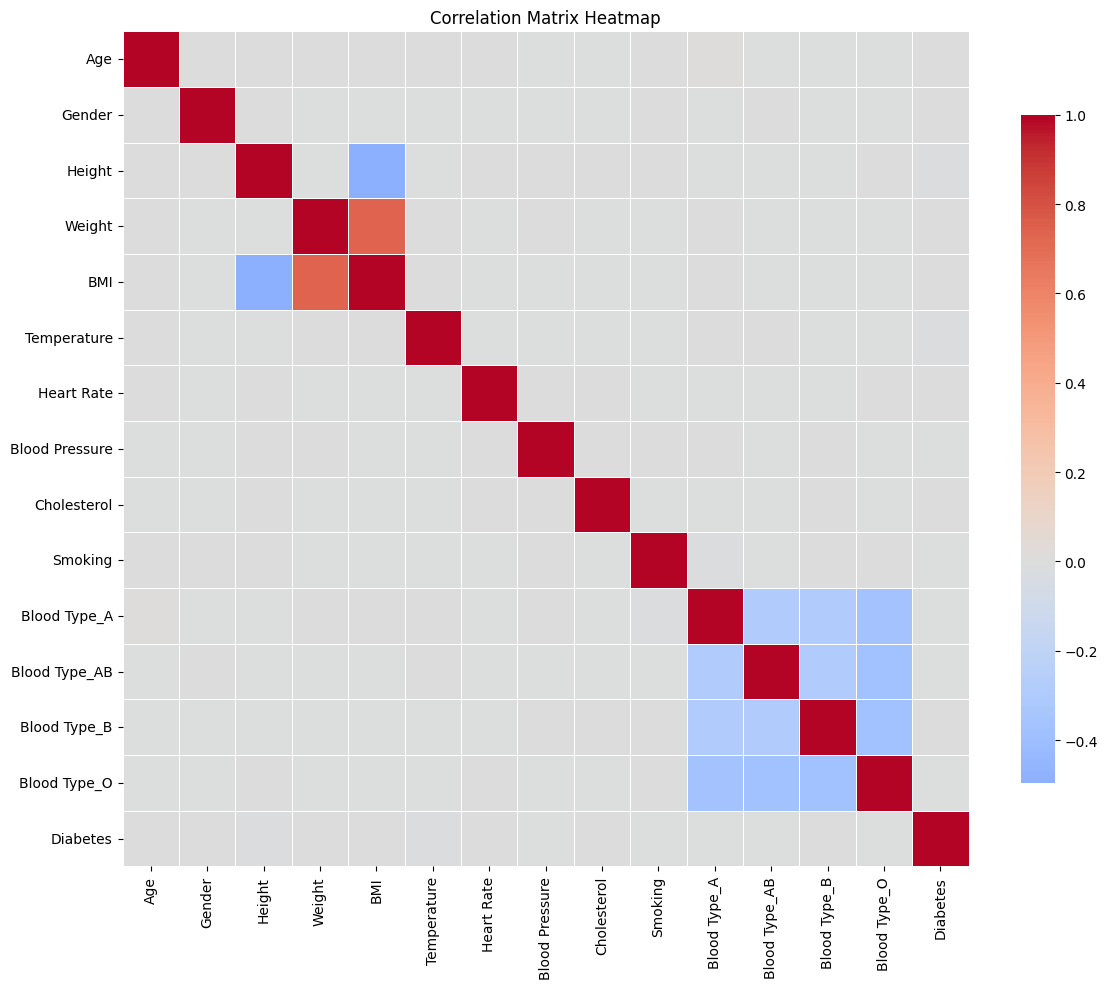


Top 10 features with highest correlation:
Height            0.006327
Temperature       0.006151
Age               0.003474
Gender            0.003416
Cholesterol       0.002751
Weight            0.002547
Heart Rate        0.002327
BMI               0.002226
Blood Type_B      0.001458
Blood Pressure    0.001317
dtype: float64




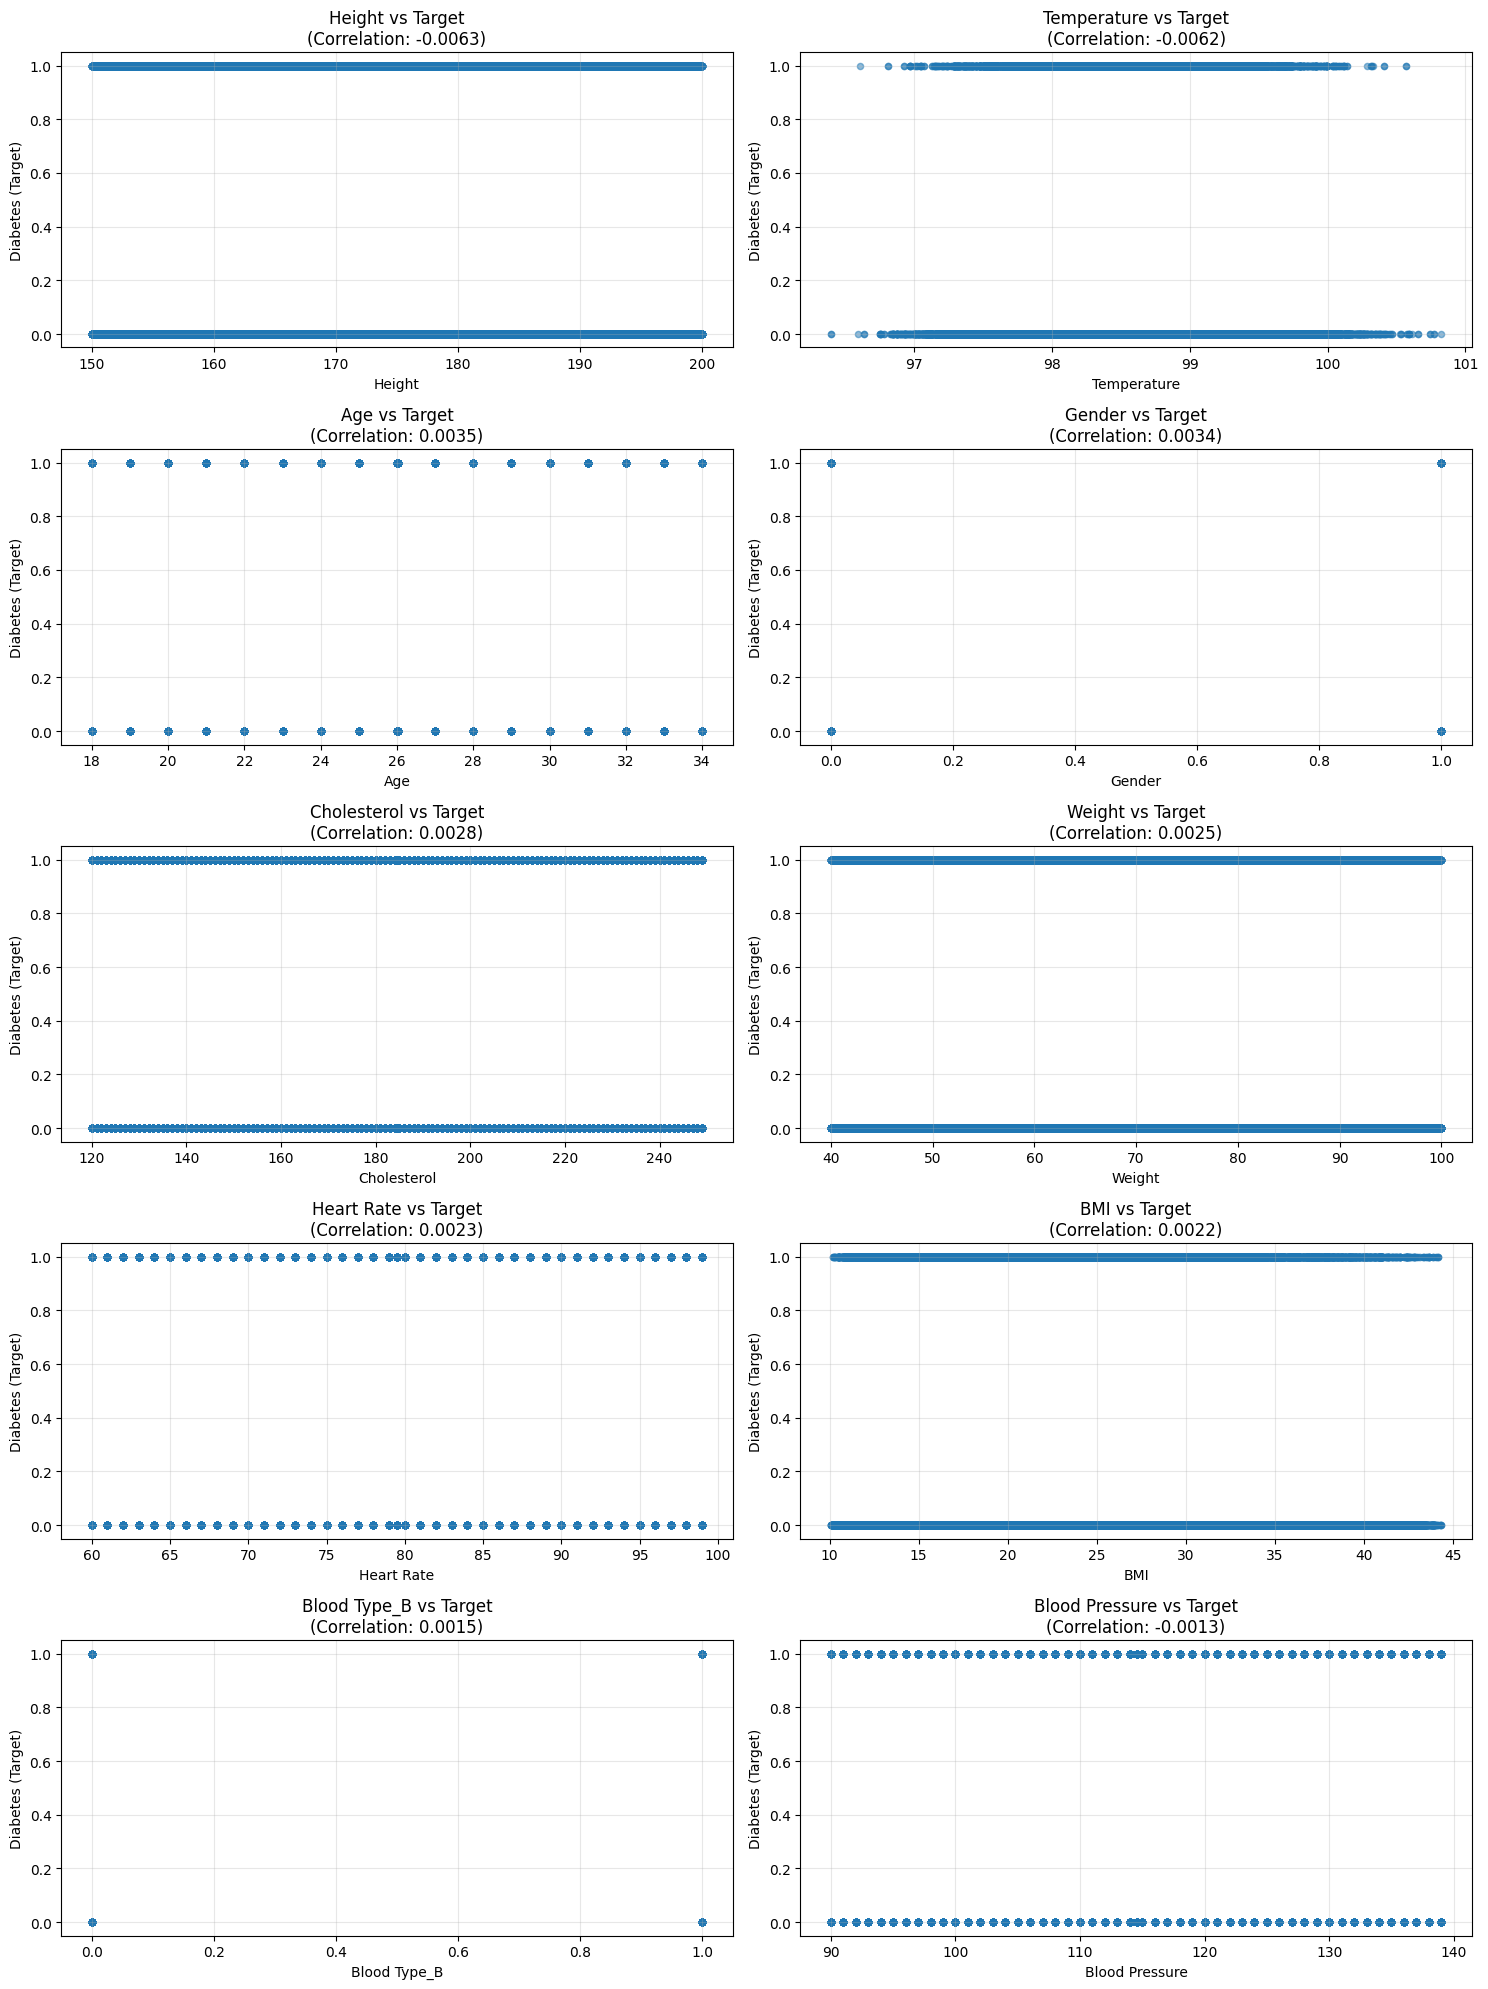

In [26]:
# 1. Calculate correlations with target
correlations = features.corrwith(target)
print("Correlation of each feature with the target variable:")
print(correlations.sort_values(ascending=False))
print("\n")

# 2. Display correlation values
correlation_df = pd.DataFrame({
    'Feature': correlations.index,
    'Correlation': correlations.values
}).sort_values('Correlation', key=abs, ascending=False)
print(correlation_df)
print("\n")

# 3. Create correlation matrix visualization
# Combine features and target for full correlation matrix
full_data = features.copy()
full_data['Diabetes'] = target

plt.figure(figsize=(12, 10))
correlation_matrix = full_data.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# 4. Select top 10 features with highest absolute correlation
top_10_features = correlations.abs().sort_values(ascending=False).head(10)
print("\nTop 10 features with highest correlation:")
print(top_10_features)
print("\n")

# 5. Create 1D scatter plots for top 10 features
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.ravel()

for idx, feature in enumerate(top_10_features.index):
    axes[idx].scatter(features[feature], target, alpha=0.5, s=20)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Diabetes (Target)')
    axes[idx].set_title(f'{feature} vs Target\n(Correlation: {correlations[feature]:.4f})')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [27]:
# # Plotting the absolute correlation values
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 6))
# correlations.abs().sort_values(ascending=False).plot(kind='bar')
# plt.title('Feature Correlation with Target Variable')
# plt.ylabel('Absolute Correlation')
# plt.xlabel('Features')
# plt.show()

### 7 Model Train

In [28]:
### Automatic Search for searching best Hyperparameters

In [29]:
# def build_model(hp):
#     model = keras.Sequential()

#       # ADD THIS: Specify input shape explicitly
#     model.add(layers.Input(shape=(features.shape[1],)))

#     for i in range(hp.Int('num_layers', 2, 4)):
#         model.add(layers.Dense(units=hp.Int('units_' + str(i),
#                                             min_value=64,
#                                             max_value=512,
#                                             step=64),
#                                activation='relu'))
#     model.add(layers.Dense(1, activation='sigmoid'))
#     model.compile(
#         optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3])),
#         loss='binary_crossentropy',
#         metrics=['accuracy', metrics.AUC(name='auc'),
#           metrics.Precision(name='precision'), metrics.Recall(name='recall')])

#         # metrics = ['accuracy', 'AUC'])
#         # metrics=['mean_absolute_error', keras.metrics.R2Score()])
#     return model

#   # =================

# tuner = kt.RandomSearch(
#     build_model,
#     objective='val_auc',
#     max_trials=5,
#     executions_per_trial=3,
#     directory='project',
#     project_name='Diabetes_Prediction'
# )
# tuner.search_space_summary()

### Manual Set Architechture

In [30]:
def build_model1():
	model = keras.Sequential([
		layers.Input(shape=(features.shape[1],)),
		layers.Dense(128, activation='relu'),
		layers.Dense(64, activation='relu'),
		layers.Dense(1, activation='sigmoid')
	])
	model.compile(
		optimizer=keras.optimizers.Adam(learning_rate=0.001),
		loss='binary_crossentropy',
		metrics=['accuracy', metrics.AUC(name='auc'), metrics.Precision(name='precision'), metrics.Recall(name='recall')]
	)
	return model


def build_model2():
	model = keras.Sequential([
		layers.Input(shape=(features.shape[1],)),
		layers.Dense(256, activation='relu'),
		layers.Dropout(0.3),
		layers.Dense(128, activation='relu'),
		layers.Dropout(0.3),
		layers.Dense(64, activation='relu'),
		layers.Dense(1, activation='sigmoid')
	])
	model.compile(
		optimizer=keras.optimizers.Adam(learning_rate=0.001),
		loss='binary_crossentropy',
		metrics=['accuracy', metrics.AUC(name='auc'), metrics.Precision(name='precision'), metrics.Recall(name='recall')]
	)
	return model


def build_model3():
	model = keras.Sequential([
		layers.Input(shape=(features.shape[1],)),
		layers.Dense(128, activation='relu'),
		layers.Dense(128, activation='relu'),
		layers.Dense(128, activation='relu'),
		layers.Dense(1, activation='sigmoid')
	])
	model.compile(
		optimizer=keras.optimizers.Adam(learning_rate=0.001),
		loss='binary_crossentropy',
		metrics=['accuracy', metrics.AUC(name='auc'), metrics.Precision(name='precision'), metrics.Recall(name='recall')]
	)
	return model


def build_model4():
	model = keras.Sequential([
		layers.Input(shape=(features.shape[1],)),
		layers.Dense(512, activation='relu'),
		layers.BatchNormalization(),
		layers.Dense(256, activation='relu'),
		layers.BatchNormalization(),
		layers.Dense(128, activation='relu'),
		layers.Dense(1, activation='sigmoid')
	])
	model.compile(
		optimizer=keras.optimizers.Adam(learning_rate=0.001),
		loss='binary_crossentropy',
		metrics=['accuracy', metrics.AUC(name='auc'), metrics.Precision(name='precision'), metrics.Recall(name='recall')]
	)
	return model

In [31]:
# Prepare scaled data for training all 4 models
X_train_scaled, X_val_scaled, X_test_scaled = scaling_with_choice('minmax')

# Compute class weights to handle imbalanced dataset
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

print("Data preparation complete!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"Class weights: {class_weights}\n")

Data preparation complete!
X_train_scaled shape: (126000, 14)
Class weights: {0: np.float64(0.5556045506658436), 1: np.float64(4.9960348929421095)}



### 7.1 Train and Evaluate All 4 Manual Architectures

In [ ]:
# ==================================================
# TRAIN MODEL 1: Simple 2-Layer Network
# ==================================================

print("="*70)
print("TRAINING MODEL 1: [128, 64] - 2 Layers")
print("="*70)

# Step 1: Build the model
model1 = build_model1()

# Step 2: Show model structure
print("\n📊 Model Architecture:")
model1.summary()

# Step 3: Set up early stopping (stops training if no improvement)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',           # Watch validation loss
    patience=15,                   # Wait 15 epochs before stopping
    restore_best_weights=True,     # Use best weights, not last
    verbose=1
)

# Step 4: Train the model
print("\n🔄 Training started...")
history1 = model1.fit(
    X_train_scaled, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1  # Show training progress
)

# Step 5: Make predictions on test set
print("\n🔮 Making predictions...")
y_pred_proba1 = model1.predict(X_test_scaled)
y_pred1 = (y_pred_proba1 > 0.5).astype(int).flatten()

# Step 6: Calculate performance metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy1 = accuracy_score(y_test, y_pred1)
precision1 = precision_score(y_test, y_pred1)
recall1 = recall_score(y_test, y_pred1)
f1_1 = f1_score(y_test, y_pred1)
auroc1 = roc_auc_score(y_test, y_pred_proba1)

# Step 7: Display results
print("\n" + "="*70)
print("✅ MODEL 1 RESULTS")
print("="*70)
print(f"Accuracy:  {accuracy1:.4f} - How many predictions were correct")
print(f"Precision: {precision1:.4f} - Of predicted positives, how many were right")
print(f"Recall:    {recall1:.4f} - Of actual positives, how many we found")
print(f"F1-Score:  {f1_1:.4f} - Balance between precision and recall")
print(f"AUROC:     {auroc1:.4f} - Overall model performance (higher is better)")
print("="*70)

In [ ]:
# ==================================================
# MODEL 1: CONFUSION MATRIX
# ==================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm1 = confusion_matrix(y_test, y_pred1)

# Create visualization
fig, ax = plt.subplots(figsize=(8, 6))
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=['No Diabetes', 'Diabetes'])
disp1.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Model 1: Confusion Matrix - [128, 64]', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretation
print("\n📊 CONFUSION MATRIX BREAKDOWN FOR MODEL 1:")
print("="*70)
print(f"True Negatives (TN):  {cm1[0,0]} - Correctly predicted No Diabetes")
print(f"False Positives (FP): {cm1[0,1]} - Incorrectly predicted Diabetes (false alarm)")
print(f"False Negatives (FN): {cm1[1,0]} - Missed Diabetes cases (dangerous!)")
print(f"True Positives (TP):  {cm1[1,1]} - Correctly predicted Diabetes")
print("="*70)
print(f"💡 What this means:")
print(f"   - Model missed {cm1[1,0]} diabetic patients (FN) - needs improvement")
print(f"   - Model had {cm1[0,1]} false alarms (FP)")
print(f"   - Recall: {cm1[1,1]/(cm1[1,1]+cm1[1,0]):.2%} - caught {cm1[1,1]} out of {cm1[1,1]+cm1[1,0]} diabetics")
print("="*70)

In [ ]:
# ==================================================
# TRAIN MODEL 2: Deeper Network with Dropout
# ==================================================

print("\n\n" + "="*70)
print("TRAINING MODEL 2: [256, 128, 64] + Dropout")
print("="*70)

# Build and train
model2 = build_model2()
print("\n📊 Model Architecture:")
model2.summary()

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

print("\n🔄 Training started...")
history2 = model2.fit(
    X_train_scaled, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate
print("\n🔮 Making predictions...")
y_pred_proba2 = model2.predict(X_test_scaled)
y_pred2 = (y_pred_proba2 > 0.5).astype(int).flatten()

accuracy2 = accuracy_score(y_test, y_pred2)
precision2 = precision_score(y_test, y_pred2)
recall2 = recall_score(y_test, y_pred2)
f1_2 = f1_score(y_test, y_pred2)
auroc2 = roc_auc_score(y_test, y_pred_proba2)

print("\n" + "="*70)
print("✅ MODEL 2 RESULTS")
print("="*70)
print(f"Accuracy:  {accuracy2:.4f}")
print(f"Precision: {precision2:.4f}")
print(f"Recall:    {recall2:.4f}")
print(f"F1-Score:  {f1_2:.4f}")
print(f"AUROC:     {auroc2:.4f}")
print("="*70)

In [ ]:
# ==================================================
# MODEL 2: CONFUSION MATRIX
# ==================================================

# Compute confusion matrix
cm2 = confusion_matrix(y_test, y_pred2)

# Create visualization
fig, ax = plt.subplots(figsize=(8, 6))
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['No Diabetes', 'Diabetes'])
disp2.plot(cmap='Greens', values_format='d', ax=ax)
plt.title('Model 2: Confusion Matrix - [256, 128, 64] + Dropout', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretation
print("\n📊 CONFUSION MATRIX BREAKDOWN FOR MODEL 2:")
print("="*70)
print(f"True Negatives (TN):  {cm2[0,0]} - Correctly predicted No Diabetes")
print(f"False Positives (FP): {cm2[0,1]} - Incorrectly predicted Diabetes (false alarm)")
print(f"False Negatives (FN): {cm2[1,0]} - Missed Diabetes cases")
print(f"True Positives (TP):  {cm2[1,1]} - Correctly predicted Diabetes")
print("="*70)
print(f"💡 Recall: {cm2[1,1]/(cm2[1,1]+cm2[1,0]):.2%} - caught {cm2[1,1]} out of {cm2[1,1]+cm2[1,0]} diabetics")
print("="*70)

In [ ]:
# ==================================================
# TRAIN MODEL 3: Uniform 3-Layer Network
# ==================================================

print("\n\n" + "="*70)
print("TRAINING MODEL 3: [128, 128, 128]")
print("="*70)

model3 = build_model3()
print("\n📊 Model Architecture:")
model3.summary()

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

print("\n🔄 Training started...")
history3 = model3.fit(
    X_train_scaled, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

print("\n🔮 Making predictions...")
y_pred_proba3 = model3.predict(X_test_scaled)
y_pred3 = (y_pred_proba3 > 0.5).astype(int).flatten()

accuracy3 = accuracy_score(y_test, y_pred3)
precision3 = precision_score(y_test, y_pred3)
recall3 = recall_score(y_test, y_pred3)
f1_3 = f1_score(y_test, y_pred3)
auroc3 = roc_auc_score(y_test, y_pred_proba3)

print("\n" + "="*70)
print("✅ MODEL 3 RESULTS")
print("="*70)
print(f"Accuracy:  {accuracy3:.4f}")
print(f"Precision: {precision3:.4f}")
print(f"Recall:    {recall3:.4f}")
print(f"F1-Score:  {f1_3:.4f}")
print(f"AUROC:     {auroc3:.4f}")
print("="*70)

In [ ]:
# ==================================================
# MODEL 3: CONFUSION MATRIX
# ==================================================

# Compute confusion matrix
cm3 = confusion_matrix(y_test, y_pred3)

# Create visualization
fig, ax = plt.subplots(figsize=(8, 6))
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=['No Diabetes', 'Diabetes'])
disp3.plot(cmap='Oranges', values_format='d', ax=ax)
plt.title('Model 3: Confusion Matrix - [128, 128, 128]', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretation
print("\n📊 CONFUSION MATRIX BREAKDOWN FOR MODEL 3:")
print("="*70)
print(f"True Negatives (TN):  {cm3[0,0]} - Correctly predicted No Diabetes")
print(f"False Positives (FP): {cm3[0,1]} - Incorrectly predicted Diabetes (false alarm)")
print(f"False Negatives (FN): {cm3[1,0]} - Missed Diabetes cases")
print(f"True Positives (TP):  {cm3[1,1]} - Correctly predicted Diabetes")
print("="*70)
print(f"💡 Recall: {cm3[1,1]/(cm3[1,1]+cm3[1,0]):.2%} - caught {cm3[1,1]} out of {cm3[1,1]+cm3[1,0]} diabetics")
print("="*70)

In [ ]:
# ==================================================
# TRAIN MODEL 4: Large Network with Batch Normalization
# ==================================================

print("\n\n" + "="*70)
print("TRAINING MODEL 4: [512, 256, 128] + BatchNorm")
print("="*70)

model4 = build_model4()
print("\n📊 Model Architecture:")
model4.summary()

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

print("\n🔄 Training started...")
history4 = model4.fit(
    X_train_scaled, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

print("\n🔮 Making predictions...")
y_pred_proba4 = model4.predict(X_test_scaled)
y_pred4 = (y_pred_proba4 > 0.5).astype(int).flatten()

accuracy4 = accuracy_score(y_test, y_pred4)
precision4 = precision_score(y_test, y_pred4)
recall4 = recall_score(y_test, y_pred4)
f1_4 = f1_score(y_test, y_pred4)
auroc4 = roc_auc_score(y_test, y_pred_proba4)

print("\n" + "="*70)
print("✅ MODEL 4 RESULTS")
print("="*70)
print(f"Accuracy:  {accuracy4:.4f}")
print(f"Precision: {precision4:.4f}")
print(f"Recall:    {recall4:.4f}")
print(f"F1-Score:  {f1_4:.4f}")
print(f"AUROC:     {auroc4:.4f}")
print("="*70)

In [ ]:
# ==================================================
# MODEL 4: CONFUSION MATRIX
# ==================================================

# Compute confusion matrix
cm4 = confusion_matrix(y_test, y_pred4)

# Create visualization
fig, ax = plt.subplots(figsize=(8, 6))
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=['No Diabetes', 'Diabetes'])
disp4.plot(cmap='Purples', values_format='d', ax=ax)
plt.title('Model 4: Confusion Matrix - [512, 256, 128] + BatchNorm', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretation
print("\n📊 CONFUSION MATRIX BREAKDOWN FOR MODEL 4:")
print("="*70)
print(f"True Negatives (TN):  {cm4[0,0]} - Correctly predicted No Diabetes")
print(f"False Positives (FP): {cm4[0,1]} - Incorrectly predicted Diabetes (false alarm)")
print(f"False Negatives (FN): {cm4[1,0]} - Missed Diabetes cases")
print(f"True Positives (TP):  {cm4[1,1]} - Correctly predicted Diabetes")
print("="*70)
print(f"💡 Recall: {cm4[1,1]/(cm4[1,1]+cm4[1,0]):.2%} - caught {cm4[1,1]} out of {cm4[1,1]+cm4[1,0]} diabetics")
print("="*70)

In [ ]:
# ==================================================
# COMPARE ALL 4 MODELS
# ==================================================

print("\n\n" + "="*90)
print("📊 FINAL MODEL COMPARISON - TEST SET RESULTS")
print("="*90)

# Create comparison table
comparison_data = {
    'Model': [
        'Model 1: [128, 64]',
        'Model 2: [256, 128, 64] + Dropout',
        'Model 3: [128, 128, 128]',
        'Model 4: [512, 256, 128] + BatchNorm'
    ],
    'Accuracy': [accuracy1, accuracy2, accuracy3, accuracy4],
    'Precision': [precision1, precision2, precision3, precision4],
    'Recall': [recall1, recall2, recall3, recall4],
    'F1-Score': [f1_1, f1_2, f1_3, f1_4],
    'AUROC': [auroc1, auroc2, auroc3, auroc4]
}

results_df = pd.DataFrame(comparison_data)
print("\n", results_df.to_string(index=False))

# Find best model based on AUROC (Area Under ROC Curve)
best_idx = results_df['AUROC'].idxmax()
print("\n" + "="*90)
print(f"🏆 BEST MODEL: {results_df.loc[best_idx, 'Model']}")
print(f"   AUROC:     {results_df.loc[best_idx, 'AUROC']:.4f}")
print(f"   F1-Score:  {results_df.loc[best_idx, 'F1-Score']:.4f}")
print(f"   Accuracy:  {results_df.loc[best_idx, 'Accuracy']:.4f}")
print("="*90)

In [ ]:
# ==================================================
# COMPARISON: ALL 4 CONFUSION MATRICES SIDE-BY-SIDE
# ==================================================

# Create a 2x2 grid of all confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices - All 4 Models', fontsize=16, fontweight='bold', y=1.00)

# Model 1
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=['No', 'Yes'])
disp1.plot(cmap='Blues', values_format='d', ax=axes[0, 0])
axes[0, 0].set_title('Model 1: [128, 64]', fontweight='bold')

# Model 2
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['No', 'Yes'])
disp2.plot(cmap='Greens', values_format='d', ax=axes[0, 1])
axes[0, 1].set_title('Model 2: [256, 128, 64] + Dropout', fontweight='bold')

# Model 3
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=['No', 'Yes'])
disp3.plot(cmap='Oranges', values_format='d', ax=axes[1, 0])
axes[1, 0].set_title('Model 3: [128, 128, 128]', fontweight='bold')

# Model 4
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=['No', 'Yes'])
disp4.plot(cmap='Purples', values_format='d', ax=axes[1, 1])
axes[1, 1].set_title('Model 4: [512, 256, 128] + BatchNorm', fontweight='bold')

plt.tight_layout()
plt.show()

# Create comparison table
print("\n📊 CONFUSION MATRIX COMPARISON TABLE:")
print("="*100)
print(f"{'Model':<35} {'TN':<8} {'FP':<8} {'FN':<8} {'TP':<8} {'Recall':<10}")
print("="*100)
print(f"{'Model 1: [128, 64]':<35} {cm1[0,0]:<8} {cm1[0,1]:<8} {cm1[1,0]:<8} {cm1[1,1]:<8} {cm1[1,1]/(cm1[1,1]+cm1[1,0]):.2%}      ")
print(f"{'Model 2: [256, 128, 64] + Dropout':<35} {cm2[0,0]:<8} {cm2[0,1]:<8} {cm2[1,0]:<8} {cm2[1,1]:<8} {cm2[1,1]/(cm2[1,1]+cm2[1,0]):.2%}      ")
print(f"{'Model 3: [128, 128, 128]':<35} {cm3[0,0]:<8} {cm3[0,1]:<8} {cm3[1,0]:<8} {cm3[1,1]:<8} {cm3[1,1]/(cm3[1,1]+cm3[1,0]):.2%}      ")
print(f"{'Model 4: [512, 256, 128] + BatchNorm':<35} {cm4[0,0]:<8} {cm4[0,1]:<8} {cm4[1,0]:<8} {cm4[1,1]:<8} {cm4[1,1]/(cm4[1,1]+cm4[1,0]):.2%}      ")
print("="*100)

print("\n🎯 INTERPRETATION GUIDE:")
print("="*100)
print("• TN (True Negatives):  Healthy people correctly identified ✓")
print("• FP (False Positives): Healthy people wrongly flagged as diabetic (false alarm)")
print("• FN (False Negatives): Diabetic patients missed (MOST CRITICAL - can be dangerous!)")
print("• TP (True Positives):  Diabetic patients correctly identified ✓")
print("• Recall = TP/(TP+FN):  Percentage of actual diabetics the model found")
print("="*100)
print("\n💡 For medical diagnosis: Higher recall is usually better (catch all diabetics)")
print("   even if it means some false alarms (FP), to avoid missing sick patients (FN).")
print("="*100)